# Keyframe agent — Phase 1

An agent learns to **store as few frames as possible** while still reconstructing a
multi-event sequence. It leverages the within-event autoregressive structure to *skip*
predictable frames and *store* at surprises. Keyframes should emerge at event onsets.

Run cells top to bottom. Poke at state between them — that's how you'll actually learn it.

### 1. Imports + hyperparameters

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

D = 10            # stim-vector dim
H = 64            # hidden dim
LAMBDA = 6.0      # weight on reconstruction (too high -> stores all; too low -> stores none)
LR = 1e-3

### 2. Models — predictor + policy
Try editing these later. That's where the learning happens.

In [2]:
class Predictor(nn.Module):
    """Given a running hidden state, predict the next frame."""
    def __init__(self):
        super().__init__()
        self.rnn = nn.GRUCell(D, H)
        self.out = nn.Linear(H, D)

    def step(self, x, h):          # one autoregressive step
        h = self.rnn(x, h)
        return self.out(h), h


class Policy(nn.Module):
    """Decide STORE vs SKIP from (actual, predicted, drift)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * D + 1, H), nn.ReLU(),
            nn.Linear(H, 2)          # logits: [skip, store]
        )

    def forward(self, actual, pred, drift):
        feat = torch.cat([actual, pred, drift.unsqueeze(0)], dim=-1)
        return self.net(feat)

### 3. The walk-forward (one video)
On **SKIP** the prediction feeds back in (true autoregressive rollout); on **STORE** the
real frame does, resetting drift. Straight-through Gumbel makes the discrete choice trainable.

In [3]:
def run_video(video, predictor, policy, tau=1.0):
    T = video.shape[0]
    h = torch.zeros(H)
    recon, gates = [], []
    store_mass = 0.0

    cur = video[0]                     # always seed with first frame
    _, h = predictor.step(cur, h)
    recon.append(video[0])

    for t in range(1, T):
        pred, h = predictor.step(cur, h)          # autoregressive step
        actual = video[t]
        drift = F.mse_loss(pred, actual).detach()

        logits = policy(actual, pred, drift)
        gate = F.gumbel_softmax(logits, tau=tau, hard=True)   # [skip, store]
        store = gate[1]

        cur = store * actual + (1 - store) * pred   # store=real frame, skip=prediction
        recon.append(cur)
        store_mass = store_mass + store
        gates.append(store.detach().item())

    recon = torch.stack(recon)
    recon_error = F.mse_loss(recon, video)
    frac_stored = store_mass / T
    loss = frac_stored + LAMBDA * recon_error
    return loss, store_mass, recon, gates

### 4. Synthetic data — your generator
Stable features = event **identity** (constant-ish per event); autoreg features = within-event
**trajectory** (OU ramp toward 0 or 1). Variable event lengths. Boundaries come from cumulative
lengths, not fixed spacing. This is the schema framing made concrete.

In [4]:
import numpy as np

def generate_stim(stim_dim=10, total_time=100, n_events=10, noise_std=0.2, seed=None):
    rng = np.random.default_rng(seed)
    event_avg_len = total_time / n_events
    event_lengths = rng.normal(event_avg_len, event_avg_len * 0.2, n_events).astype(int)
    event_lengths = np.clip(event_lengths, 5, None)
    event_lengths[-1] = total_time - event_lengths[:-1].sum()
    event_lengths[-1] = max(event_lengths[-1], 5)   # robustness: avoid negative last event

    stim = np.zeros((total_time, stim_dim))
    templates, dirs, af_list = [], [], []
    start = 0
    for ei in range(n_events):
        L = event_lengths[ei]
        size = rng.integers(stim_dim // 4, stim_dim // 2 + 1)
        af = rng.choice(stim_dim, size, replace=False); af_list.append(af)
        sf = np.setdiff1d(np.arange(stim_dim), af)
        d = int(rng.integers(0, 2)); dirs.append(d)
        target = 0.0 if d == 0 else 1.0
        pull = 1.0 / L
        tmpl = rng.random(stim_dim); templates.append(tmpl.copy())
        xp = tmpl[af].copy()
        for et in range(L):
            t = start + et
            xt = xp + pull * (target - xp) + rng.normal(0, noise_std, len(af))
            xt = np.clip(xt, 0, 1); stim[t, af] = xt; xp = xt
            stim[t, sf] = np.clip(tmpl[sf] + rng.normal(0, noise_std, len(sf)), 0, 1)
        start += L
    return dict(stim=stim, event_lengths=event_lengths,
                event_templates=np.array(templates),
                autoreg_directions=np.array(dirs), autoreg_features=af_list)

def make_video(seed=None):
    """Adapter: numpy dict -> (torch video, boundary indices)."""
    out = generate_stim(stim_dim=D, seed=seed)
    video = torch.tensor(out["stim"], dtype=torch.float32)
    boundaries = np.concatenate([[0], np.cumsum(out["event_lengths"])[:-1]])
    return video, boundaries

# fixed train set (each video gets its own structure)
train_data = [make_video(seed=s) for s in range(5)]
train_videos = [v for v, _ in train_data]
print("one video shape:", train_videos[0].shape)
print("its boundaries :", train_data[0][1])

one video shape: torch.Size([100, 10])
its boundaries : [ 0 10 19 30 40 48 58 70 81 89]


### 5. Train
Watch the held-out count taper as the predictor matures.

In [5]:
predictor = Predictor()
policy = Policy()
opt = torch.optim.Adam(list(predictor.parameters()) + list(policy.parameters()), lr=LR)

hist = {"epoch": [], "loss": [], "stored": [], "recon": []}
EPOCHS = 200

for epoch in range(EPOCHS):
    tau = max(0.5, 0.95 ** epoch)            # anneal: soft -> sharp
    ep_loss = ep_stored = ep_recon = 0.0
    for video in train_videos:
        loss, n_stored, recon, _ = run_video(video, predictor, policy, tau=tau)
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item(); ep_stored += n_stored.item()
        ep_recon += F.mse_loss(recon, video).item()

    n = len(train_videos)
    hist["epoch"].append(epoch); hist["loss"].append(ep_loss/n)
    hist["stored"].append(ep_stored/n); hist["recon"].append(ep_recon/n)

    if epoch % 20 == 0:
        with torch.no_grad():
            ev_v, _ = make_video(seed=999)
            _, ns, _, _ = run_video(ev_v, predictor, policy, tau=0.5)
        print(f"epoch {epoch:3d}  held-out stored ~ {ns.item():.0f} / 100")

/home/nuttidalab/miniconda3/envs/narrative_map/lib/python3.11/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch   0  held-out stored ~ 54 / 100
epoch  20  held-out stored ~ 10 / 100
epoch  40  held-out stored ~ 17 / 100
epoch  60  held-out stored ~ 23 / 100
epoch  80  held-out stored ~ 13 / 100
epoch 100  held-out stored ~ 23 / 100
epoch 120  held-out stored ~ 26 / 100
epoch 140  held-out stored ~ 26 / 100
epoch 160  held-out stored ~ 22 / 100
epoch 180  held-out stored ~ 15 / 100


### 6. Inspect — do keyframes land on boundaries?
Numbers, not eyeballs. Check the lag direction (store should be at/after a boundary, never before).

In [6]:
with torch.no_grad():
    v, BOUNDARIES = make_video(seed=999)
    _, _, _, gates = run_video(v, predictor, policy, tau=0.5)

stored_idx = [0] + [i + 1 for i, g in enumerate(gates) if g > 0.5]
print("boundaries :", list(BOUNDARIES))
print("stored idx :", stored_idx, f"  (total {len(stored_idx)})")
print("\nnearest boundary -> stored frame:")
for b in BOUNDARIES:
    nearest = min(stored_idx, key=lambda s: abs(s - b))
    print(f"  boundary {b:3d} -> stored {nearest:3d}  (lag {nearest - b:+d})")

boundaries : [np.int64(0), np.int64(11), np.int64(20), np.int64(25), np.int64(34), np.int64(45), np.int64(53), np.int64(62), np.int64(70), np.int64(80)]
stored idx : [0, 3, 4, 8, 9, 14, 15, 20, 25, 26, 37, 40, 48, 49, 50, 51, 56, 57, 68, 76, 77, 80, 82, 87, 93]   (total 25)

nearest boundary -> stored frame:
  boundary   0 -> stored   0  (lag +0)
  boundary  11 -> stored   9  (lag -2)
  boundary  20 -> stored  20  (lag +0)
  boundary  25 -> stored  25  (lag +0)
  boundary  34 -> stored  37  (lag +3)
  boundary  45 -> stored  48  (lag +3)
  boundary  53 -> stored  51  (lag -2)
  boundary  62 -> stored  57  (lag -5)
  boundary  70 -> stored  68  (lag -2)
  boundary  80 -> stored  80  (lag +0)


### 7. Plots

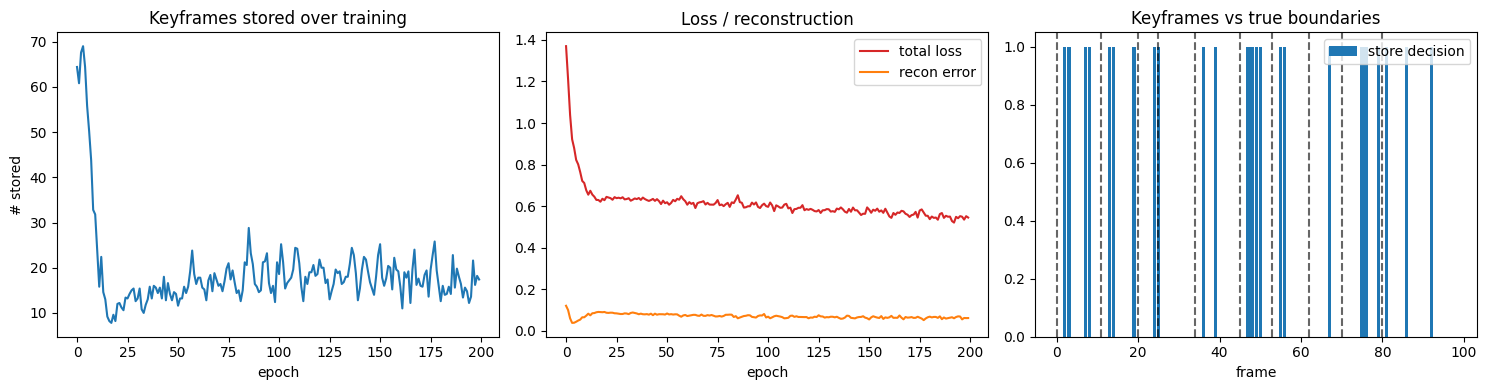

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(hist["epoch"], hist["stored"], color="tab:blue")
ax[0].set_title("Keyframes stored over training")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("# stored")

ax[1].plot(hist["epoch"], hist["loss"], label="total loss", color="tab:red")
ax[1].plot(hist["epoch"], hist["recon"], label="recon error", color="tab:orange")
ax[1].set_title("Loss / reconstruction"); ax[1].set_xlabel("epoch"); ax[1].legend()

ax[2].bar(range(len(gates)), gates, color="tab:blue", label="store decision")
for b in BOUNDARIES:
    ax[2].axvline(b, color="k", linestyle="--", alpha=0.6)
ax[2].set_title("Keyframes vs true boundaries")
ax[2].set_xlabel("frame"); ax[2].legend()

plt.tight_layout(); plt.show()

### Things to try (this is how you learn it)
- Set `LAMBDA = 1` → watch it collapse to storing nothing. Then `LAMBDA = 30` → stores everything.
- Inside `run_video`, `print(drift)` to see surprise spike at boundaries.
- Replace the predictor with **persistence** (`pred = cur`) as a control — does it still find boundaries?
- Track rollout error at the mid-event extra keyframes — meaningful drift, or noise?